##Dataset Load and eval

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset

class HFImageDataset(Dataset):
    """Custom Dataset LOader ."""
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        # Convert to RGB to ensure exactly 3 channels
        image = item['image'].convert('RGB')
        label = item['label']

        if self.transform:
            image = self.transform(image)

        return image, label

def get_dataloaders(dataset_id="Chiranjeev007/STL-10_Subset", batch_size=32):
    """Loads the dataset, applies transforms, and returns DataLoaders."""
    print(f"Loading dataset: {dataset_id}")
    dataset = load_dataset(dataset_id)

    # Detect the number of classes dynamically
    try:
        num_classes = len(dataset['train'].features['label'].names)
    except Exception:
        num_classes = 10 # Fallback default for STL-10

    # Pretrained ResNet-18 expects 224x224 input and specific ImageNet normalization
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Apply transforms
    train_ds = HFImageDataset(dataset['train'], transform=train_transforms)

    # Extract Test/Validation data. If neither exists, generate an 80/20 split.
    if 'test' in dataset:
        test_ds = HFImageDataset(dataset['test'], transform=test_transforms)
    elif 'validation' in dataset:
        test_ds = HFImageDataset(dataset['validation'], transform=test_transforms)
    else:
        print("Creating an 80/20 train/val split...")
        split = dataset['train'].train_test_split(test_size=0.2, seed=42)
        train_ds = HFImageDataset(split['train'], transform=train_transforms)
        test_ds = HFImageDataset(split['test'], transform=test_transforms)

    # Create DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

    return train_loader, test_loader, num_classes

###MOdel eval


In [7]:
import torch
import torch.nn as nn
from torchvision import models

def get_resnet18(num_classes, device):
    """
    Loads a pretrained ResNet-18 model and modified the final
    fully connected layer to match our dataset's number of classes.
    """
    print("Loading pretrained ResNet-18...")
    # Load pretrained weights
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Replace the final fully connected layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    # Move model to the correct device (GPU/CPU)
    model = model.to(device)
    return model

###Main Execution

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
import os

# Import from our modular files
# from dataset import get_dataloaders
# from model import get_resnet18

def main():
    # 1. Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 2. Hyperparameters
    dataset_id = "Chiranjeev007/STL-10_Subset"
    batch_size = 32
    epochs = 5
    learning_rate = 3e-4

    # 3. Load Data & Model
    train_loader, test_loader, num_classes = get_dataloaders(dataset_id, batch_size)
    model = get_resnet18(num_classes, device)

    # 4. Setup Loss function and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # 5. Weights & Biases Logging
    print("--- Logging into Weights & Biases ---")
    wandb.login()
    wandb.init(
        project="resnet18-stl10-subset",
        name="resnet18-finetuning",
        config={
            "learning_rate": learning_rate,
            "architecture": "ResNet-18",
            "dataset": dataset_id,
            "epochs": epochs,
            "batch_size": batch_size
        }
    )

    # 6. Training Loop
    print("\n Started Training")
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        # --- VALIDATION ---
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(test_loader)
        val_acc = 100 * correct_val / total_val

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Log all metrics to W&B
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc
        })

    wandb.finish()

    # 7. Save the model locally
    model_path = "resnet18_stl10_subset.pth"
    torch.save(model.state_dict(), model_path)
    print(f"\nTraining complete! Model saved locally to {model_path}")

if __name__ == "__main__":
    main()

Using device: cuda
Loading dataset: Chiranjeev007/STL-10_Subset
Train batches: 157 | Test batches: 32
Loading pretrained ResNet-18...
--- Logging into Weights & Biases ---


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: vidhan-savaliya (vidhan-savaliya-indian-institute-of-technology-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



 Started Training
Epoch [1/5] | Train Loss: 0.7990 | Train Acc: 72.24% | Val Loss: 0.6867 | Val Acc: 80.70%
Epoch [2/5] | Train Loss: 0.6332 | Train Acc: 77.88% | Val Loss: 0.3889 | Val Acc: 87.70%
Epoch [3/5] | Train Loss: 0.5470 | Train Acc: 80.18% | Val Loss: 0.4451 | Val Acc: 85.70%
Epoch [4/5] | Train Loss: 0.5212 | Train Acc: 82.08% | Val Loss: 0.4284 | Val Acc: 88.30%
Epoch [5/5] | Train Loss: 0.4927 | Train Acc: 82.74% | Val Loss: 0.4453 | Val Acc: 86.80%


epoch,▁▃▅▆█
train_accuracy,▁▅▆██
train_loss,█▄▂▂▁
val_accuracy,▁▇▆█▇
val_loss,█▁▂▂▂
epoch,5
train_accuracy,82.74
train_loss,0.49269
val_accuracy,86.8
val_loss,0.44527



Training complete! Model saved locally to resnet18_stl10_subset.pth


### HUgging Face upload

In [15]:
from huggingface_hub import HfApi, login

def push_model_to_hf(model_path, hf_username, repo_name):
    """
    Pushes a locally saved model to the Hugging Face Hub.
    """
    print("--- Logging into Hugging Face Hub ---")
    # Will prompt you for your token if not already logged in
    login()

    repo_id = f"{hf_username}/{repo_name}"
    api = HfApi()

    try:
        # Create repository (if it doesn't already exist)
        print(f"Preparing repository: {repo_id}...")
        api.create_repo(repo_id=repo_id, exist_ok=True)

        # Upload the weights
        print(f"Uploading model {model_path}...")
        api.upload_file(
            path_or_fileobj=model_path,
            path_in_repo=model_path,
            repo_id=repo_id,
            repo_type="model",
        )
        print(f"\nSuccess! Model pushed to: https://huggingface.co/{repo_id}")
    except Exception as e:
        print(f"Failed to push to the Hub. Error details: {e}")

if __name__ == "__main__":
    # -------- IMPORTANT --------
    # Replace this with your actual Hugging Face Username
    HF_USERNAME = "Vidhansavaliya123"

    MODEL_PATH = "resnet18_stl10_subset.pth"
    REPO_NAME = "resnet18-stl10-subset"

    push_model_to_hf(MODEL_PATH, HF_USERNAME, REPO_NAME)

--- Logging into Hugging Face Hub ---
Preparing repository: Vidhansavaliya123/resnet18-stl10-subset...
Uploading model resnet18_stl10_subset.pth...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  resnet18_stl10_subset.pth   :   1%|1         |  566kB / 44.8MB            


Success! Model pushed to: https://huggingface.co/Vidhansavaliya123/resnet18-stl10-subset


##Model evaluation

In [17]:
import torch
from datasets import load_dataset

# Import our custom functions from the previously created files
# from dataset import get_dataloaders
# from model import get_resnet18

def evaluate_model(model_path="resnet18_stl10_subset.pth", dataset_id="Chiranjeev007/STL-10_Subset", batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. Get Dataloaders (we only really need the test_loader here)
    _, test_loader, num_classes = get_dataloaders(dataset_id, batch_size)

    # Fetch class names directly from the Hugging Face dataset features for pretty printing
    print("Fetching class names...")
    raw_dataset = load_dataset(dataset_id)
    try:
        class_names = raw_dataset['train'].features['label'].names
    except Exception:
        # Fallback if names are missing
        class_names = [f"Class_{i}" for i in range(num_classes)]

    # 2. Load the Model Architecture and Weights
    model = get_resnet18(num_classes, device)
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Successfully loaded model weights from {model_path}")
    except FileNotFoundError:
        print(f"Error: Model file '{model_path}' not found. Please run train.py first to train and save the model.")
        return

    model.eval()

    # 3. Initialize trackers for accuracy
    correct_overall = 0
    total_overall = 0

    # Dictionaries to track correct predictions and total samples per class
    class_correct = {classname: 0 for classname in class_names}
    class_total = {classname: 0 for classname in class_names}

    # 4. Evaluation Loop
    print("\n--- Starting Evaluation ---")
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            # Update overall accuracy trackers
            total_overall += labels.size(0)
            correct_overall += (predicted == labels).sum().item()

            # Update class-wise accuracy trackers
            for i in range(labels.size(0)):
                label_idx = labels[i].item()
                pred_idx = predicted[i].item()

                classname = class_names[label_idx]
                class_total[classname] += 1

                if label_idx == pred_idx:
                    class_correct[classname] += 1

    # 5. Calculate and Print Results
    final_accuracy = 100 * correct_overall / total_overall
    print(f"Final Overall Test Accuracy: {final_accuracy:.2f}%")

    print("\nClass-wise Accuracy-")
    for classname in class_names:
        if class_total[classname] > 0:
            acc = 100 * class_correct[classname] / class_total[classname]
            print(f"{classname:12s} : {acc:5.2f}%  ({class_correct[classname]}/{class_total[classname]} correct)")
        else:
            print(f"{classname:12s} : N/A (No samples found in the test set)")

if __name__ == "__main__":
    evaluate_model()

Using device: cuda
Loading dataset: Chiranjeev007/STL-10_Subset
Train batches: 157 | Test batches: 32
Fetching class names...
Loading pretrained ResNet-18...
Successfully loaded model weights from resnet18_stl10_subset.pth

--- Starting Evaluation ---
Final Overall Test Accuracy: 86.80%

Class-wise Accuracy-
airplane     : 87.00%  (87/100 correct)
bird         : 90.00%  (90/100 correct)
car          : 87.00%  (87/100 correct)
cat          : 83.00%  (83/100 correct)
deer         : 81.00%  (81/100 correct)
dog          : 71.00%  (71/100 correct)
horse        : 95.00%  (95/100 correct)
monkey       : 96.00%  (96/100 correct)
ship         : 96.00%  (96/100 correct)
truck        : 82.00%  (82/100 correct)


Results

Using device: cuda
Loading dataset: Chiranjeev007/STL-10_Subset
Train batches: 157 | Test batches: 32
Fetching class names...
Loading pretrained ResNet-18...
Successfully loaded model weights from resnet18_stl10_subset.pth
Evaluating test set to collect samples and calculate class-wise accuracy...
Found 10 correct and 10 incorrect samples.
Saved visualization to 'prediction_samples.png'

Generating Class-wise Accuracy Bar Chart...
Saved bar chart to 'class_accuracy_bar_chart.png'


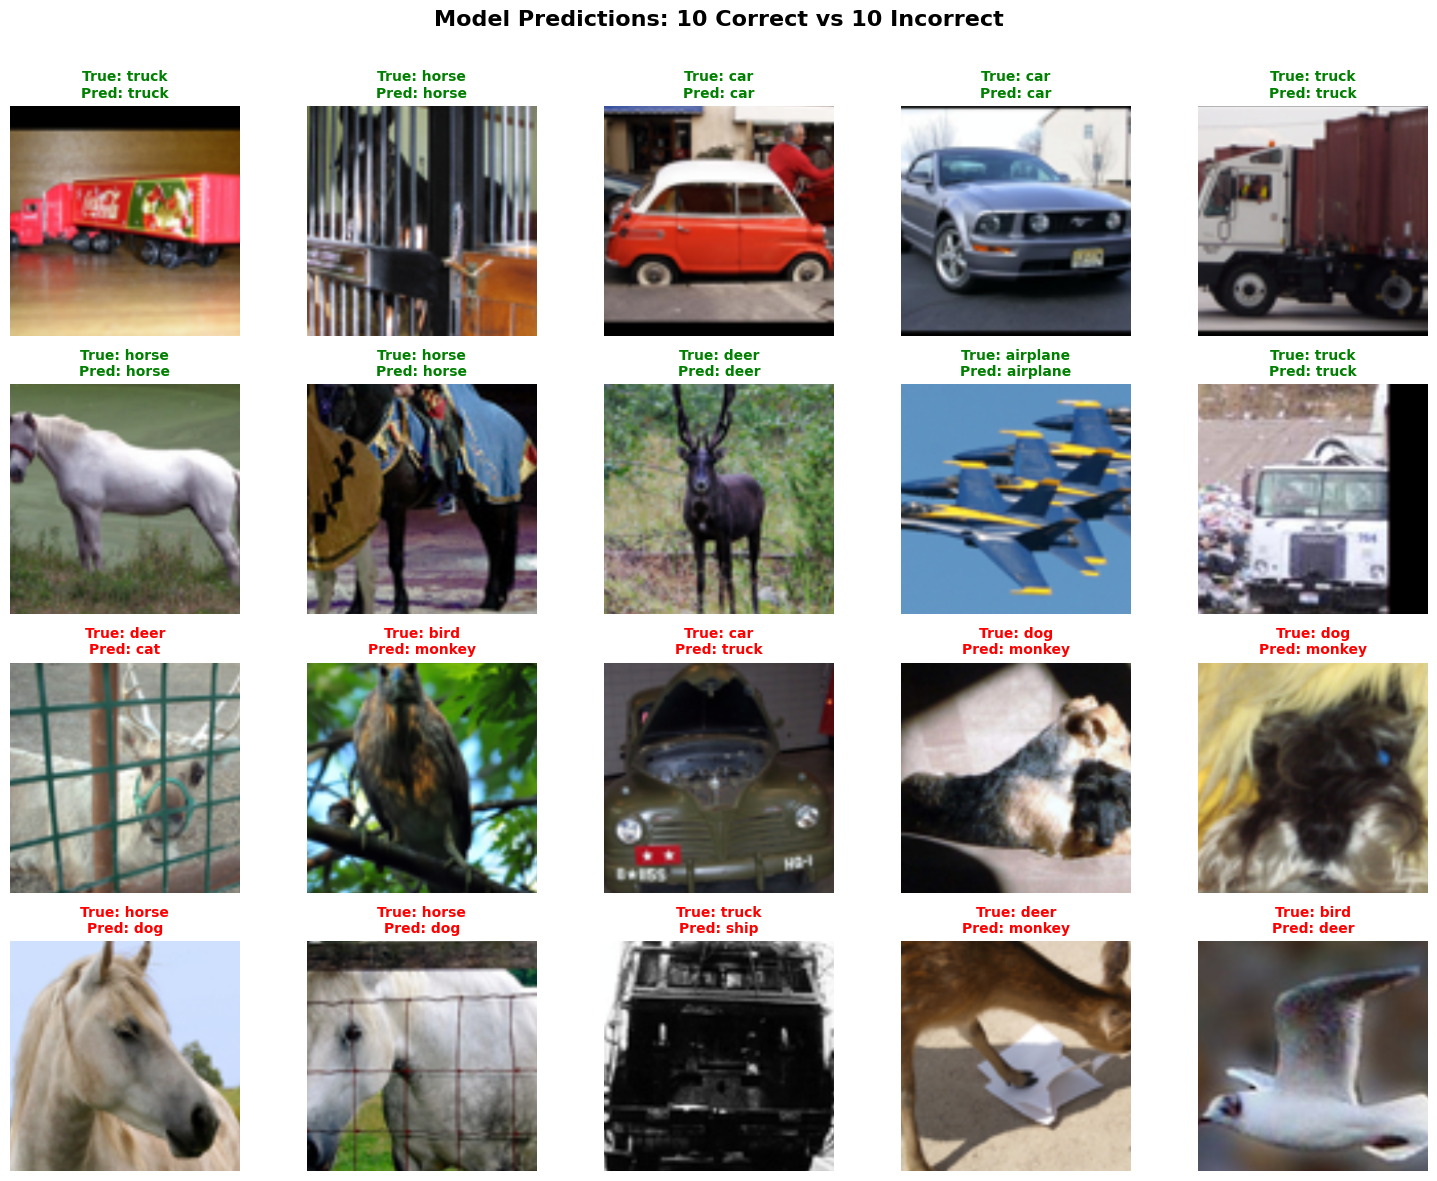

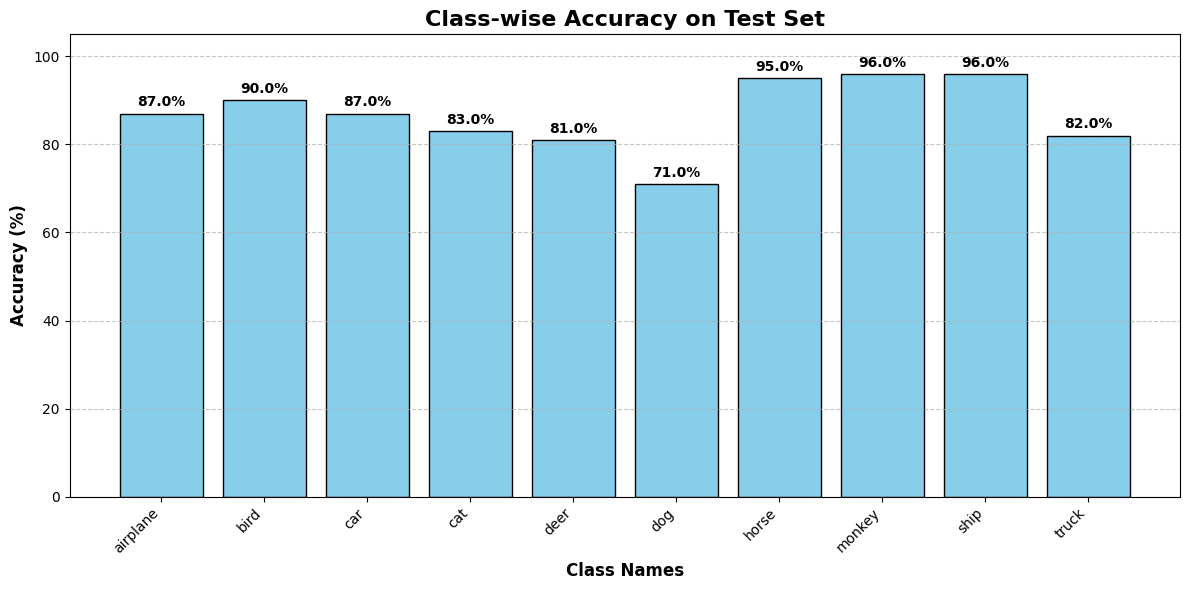

In [23]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import argparse
from datasets import load_dataset



def unnormalize(image_tensor):
    """
    Reverses the ImageNet normalization so we can display the image correctly.
    """
    image = image_tensor.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)
    return image

def visualize_samples(model_path="resnet18_stl10_subset.pth", dataset_id="Chiranjeev007/STL-10_Subset", batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. Get Dataloaders
    _, test_loader, num_classes = get_dataloaders(dataset_id, batch_size)

    # 2. Fetch class names
    print("Fetching class names...")
    raw_dataset = load_dataset(dataset_id)
    try:
        class_names = raw_dataset['train'].features['label'].names
    except Exception:
        class_names = [f"Class_{i}" for i in range(num_classes)]

    # 3. Load the Model
    model = get_resnet18(num_classes, device)
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Successfully loaded model weights from {model_path}")
    except FileNotFoundError:
        print(f"Error: Model file '{model_path}' not found. Please train the model first.")
        return

    model.eval()

    correct_samples = []
    incorrect_samples = []

    # Tracking class-wise accuracy metrics
    class_correct = {classname: 0 for classname in class_names}
    class_total = {classname: 0 for classname in class_names}

    # 4. Run inference to collect samples and metrics
    print("Evaluating test set to collect samples and calculate class-wise accuracy...")
    with torch.no_grad():
        for images, labels in test_loader:
            images_device, labels_device = images.to(device), labels.to(device)
            outputs = model(images_device)
            _, predicted = torch.max(outputs, 1)

            for i in range(labels.size(0)):
                img = images[i]
                true_label = labels[i].item()
                pred_label = predicted[i].item()

                classname = class_names[true_label]
                class_total[classname] += 1

                sample_data = (img, class_names[true_label], class_names[pred_label])

                if true_label == pred_label:
                    class_correct[classname] += 1
                    if len(correct_samples) < 10:
                        correct_samples.append(sample_data)
                else:
                    if len(incorrect_samples) < 10:
                        incorrect_samples.append(sample_data)

                # Note: The 'break' statement is removed so it iterates
                # through the entire test set to calculate accurate class-wise stats.

    # 5. Plotting
    print(f"Found {len(correct_samples)} correct and {len(incorrect_samples)} incorrect samples.")

    fig = plt.figure(figsize=(15, 12))
    fig.suptitle("Model Predictions: 10 Correct vs 10 Incorrect", fontsize=16, fontweight='bold', y=0.98)

    # Plot Correct Samples
    for idx, (img_tensor, true_lbl, pred_lbl) in enumerate(correct_samples):
        ax = fig.add_subplot(4, 5, idx + 1)
        ax.imshow(unnormalize(img_tensor))
        ax.axis('off')
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color="green", fontsize=10, fontweight='bold')

    # Plot Incorrect Samples
    for idx, (img_tensor, true_lbl, pred_lbl) in enumerate(incorrect_samples):
        # Offset index by 10 to put them in the bottom two rows
        ax = fig.add_subplot(4, 5, idx + 11)
        ax.imshow(unnormalize(img_tensor))
        ax.axis('off')
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color="red", fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)

    # Save image grid
    save_path = "prediction_samples.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"Saved visualization to '{save_path}'")

    # 6. Plotting Class-wise Accuracy Bar Chart
    print("\nGenerating Class-wise Accuracy Bar Chart...")
    plot_classes = []
    plot_accuracies = []

    for classname in class_names:
        if class_total[classname] > 0:
            acc = 100 * class_correct[classname] / class_total[classname]
            plot_classes.append(classname)
            plot_accuracies.append(acc)

    if plot_classes:
        fig2 = plt.figure(figsize=(12, 6))
        bars = plt.bar(plot_classes, plot_accuracies, color='skyblue', edgecolor='black')

        plt.xlabel('Class Names', fontsize=12, fontweight='bold')
        plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
        plt.title('Class-wise Accuracy on Test Set', fontsize=16, fontweight='bold')
        plt.ylim(0, 105)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Attach text labels above each bar
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

        plt.tight_layout()
        save_path_bar = "class_accuracy_bar_chart.png"
        plt.savefig(save_path_bar, bbox_inches='tight', dpi=150)
        print(f"Saved bar chart to '{save_path_bar}'")

    # Display both plots
    plt.show()

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Visualize model predictions.")
    parser.add_argument("--model_path", type=str, default="resnet18_stl10_subset.pth",
                        help="Path to the saved model weights")
    args = parser.parse_args([]) # Pass an empty list to ignore kernel arguments

    visualize_samples(model_path=args.model_path)